## **The Left-Handed Problem: From Sample to Population**

Let's imagine: we surveyed 100 people, and 20 of them are left-handed.  
Our estimate is 20%. But does this mean that exactly 20% of the entire population  
is left-handed?  
Spiegelhalter shows that we need to imagine a Sampling Distribution.  
If we sampled 100 people a thousand times, we would get slightly different  
numbers each time (18, 22, 15, 25...).  
**The math says:** These results will cluster around the true value in the familiar  
"bell" shape. 

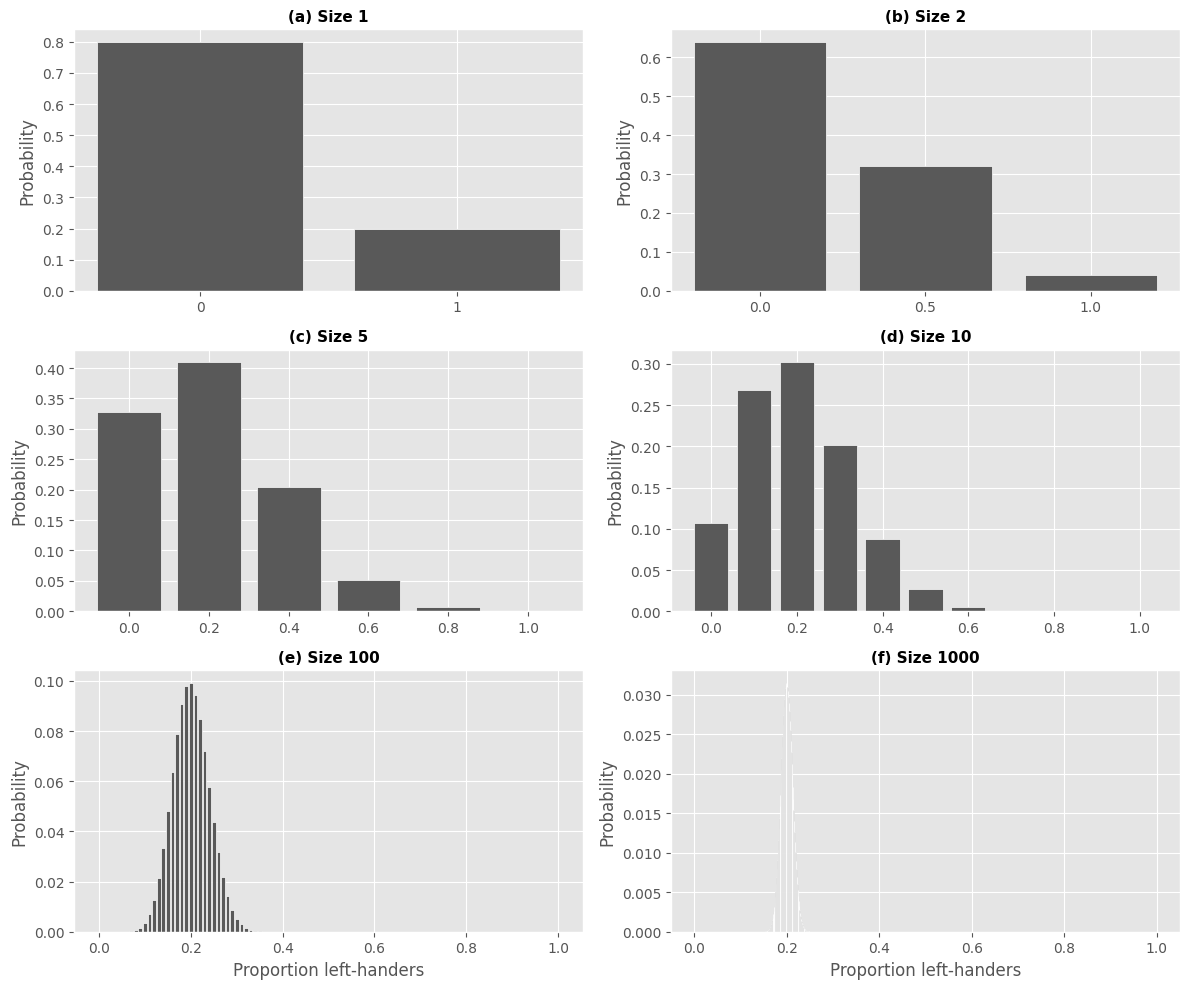


Probabilities of getting at least 30%:
n=1    : 2.000000e-01
n=2    : 3.600000e-01
n=5    : 2.627200e-01
n=10   : 1.208739e-01
n=100  : 6.059335e-03
n=1000 : 2.201699e-14


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom


n_values = [1, 2, 5, 10, 100, 1000]
pleft = 0.2
labels = ["(a) Size 1", "(b) Size 2", "(c) Size 5", "(d) Size 10", "(e) Size 100", "(f) Size 1000"]

# Set ggplot style
plt.style.use('ggplot')


fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()  # Flatten to iterate easily

for i, n in enumerate(n_values):
    # Generate x values (number of left-handers)
    x = np.arange(0, n + 1)
    
    # Calculate probabilities (equivalent to dbinom in R)
    y = binom.pmf(x, n, pleft)
    
    # Calculate proportions
    proportion = x / n
    
    # Calculate dynamic bar width to avoid overlapping
    bar_width = 0.8 / n if n > 0 else 0.8
    
    # Create the bar chart
    axes[i].bar(proportion, y, width=bar_width, color='#595959', edgecolor='white', align='center')
    
    # Set titles and labels
    axes[i].set_title(labels[i], fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Probability")
    
    # Add x-axis label only to the bottom two plots (like in the R code)
    if i >= 4:
        axes[i].set_xlabel("Proportion left-handers")
        
    # Set custom x-axis breaks based on n (equivalent to scale_x_continuous)
    if n == 1:
        axes[i].set_xticks([0, 1])
    elif n == 2:
        axes[i].set_xticks([0, 0.5, 1.0])
    else:
        axes[i].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Probabilities of getting at least 30% ---

print("\nProbabilities of getting at least 30%:")

# Convert n_values to a numpy array for vectorized operations
n_arr = np.array(n_values)

# In R, pbinom(q, n, p, lower.tail=FALSE) calculates P(X > q).
# The equivalent in scipy is the survival function (sf): sf(k, n, p) = P(X > k)
# We use np.floor(0.3 * n_arr) to match how R handles non-integer quantiles internally.
q = np.floor(0.3 * n_arr)
probabilities = binom.sf(q, n_arr, pleft)

# Print the results in scientific notation, matching the R output format
for i, prob in enumerate(probabilities):
    print(f"n={n_values[i]:<4} : {prob:e}")

## **The Central Limit Theorem**

The bottom line: It doesn't matter what shape your original data is  
(it can be odd, skewed, or binary). If you take a large enough sample  
and calculate the mean, the distribution of those means will always be normal.  
**Why is this important?** This allows us to use the "bell curve" rules

## **Confidence Intervals — CI**

This is probably the most misunderstood concept in science.  

**95% Confidence Interval:** This does not mean that there is a 95%  
chance that the true number lies within this particular interval  
(although that sounds logical).

True value: This means that if we repeat our study 100 times and  
calculate this interval each time, then 95 times out of 100 our  
interval will "catch" the truth.

Spiegelhalter uses a great metaphor: it's like throwing rings at a peg.  
The peg (the truth) is stationary. We throw the ring (the confidence interval).  
95% of our throws will be successful.

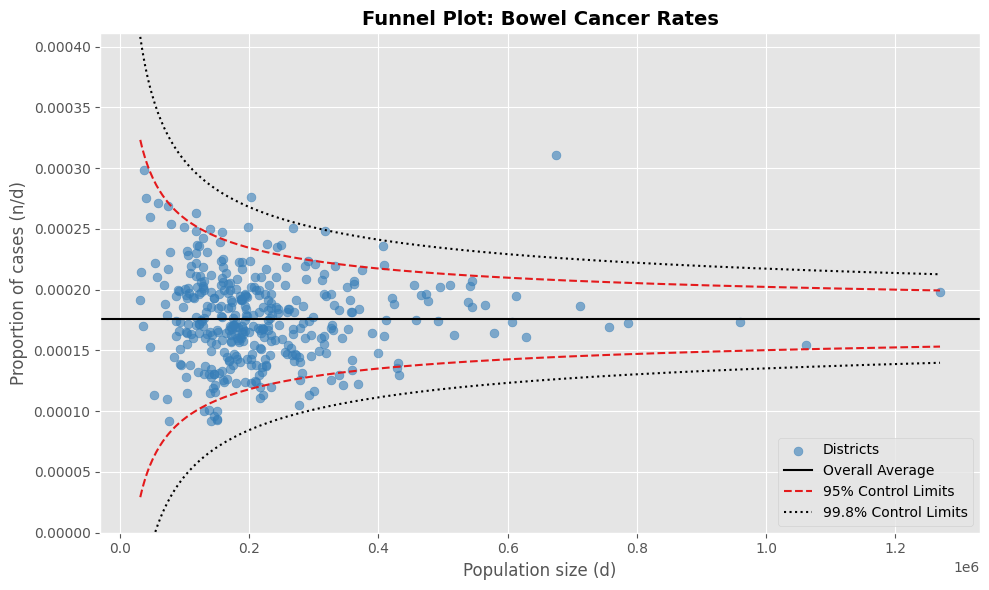

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('bowel-cancer-data-x.csv')

pop_col = 'd'    
cases_col = 'n' 


df['proportion'] = df[cases_col] / df[pop_col]


overall_p = df[cases_col].sum() / df[pop_col].sum()


n_seq = np.linspace(df[pop_col].min(), df[pop_col].max(), 500)

se_seq = np.sqrt(overall_p * (1 - overall_p) / n_seq)

z_95 = 1.96
upper_95 = overall_p + z_95 * se_seq
lower_95 = overall_p - z_95 * se_seq

z_998 = 3.09
upper_998 = overall_p + z_998 * se_seq
lower_998 = overall_p - z_998 * se_seq


plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df[pop_col], df['proportion'], alpha=0.6, color='#377EB8', s=40, label='Districts')

ax.axhline(overall_p, color='black', linestyle='-', linewidth=1.5, label='Overall Average')

ax.plot(n_seq, upper_95, color='#E41A1C', linestyle='--', linewidth=1.5, label='95% Control Limits')
ax.plot(n_seq, lower_95, color='#E41A1C', linestyle='--', linewidth=1.5)

ax.plot(n_seq, upper_998, color='black', linestyle=':', linewidth=1.5, label='99.8% Control Limits')
ax.plot(n_seq, lower_998, color='black', linestyle=':', linewidth=1.5)

ax.set_title("Funnel Plot: Bowel Cancer Rates", fontsize=14, fontweight='bold')
ax.set_xlabel("Population size (d)", fontsize=12)
ax.set_ylabel("Proportion of cases (n/d)", fontsize=12)

plt.ylim(0, df['proportion'].max() + 0.0001)

ax.legend(loc='lower right')
plt.tight_layout()

plt.show()

## **Bowel-cancer death rates**

Here the author warns against the "fallacy of small numbers."  
In some areas, the mortality rate seems to be three times higher.  
**Why?** Because these areas are small! In a small sample, randomness plays  
a huge role. One additional death can double the statistics.  
When we build confidence intervals for such areas, they turn out to be huge,  
which shows that we really don't know anything for sure.  

## **Margin of Error**

When we see the results of polls (for example, before elections),  
there is always an error of $\pm 3\%$.  
The author reminds us: this error only takes into account Sampling Error  
(random sampling error).  
It does not take into account systematic errors: people lie, people do not answer  
the phone, the question is formulated incorrectly. Therefore, the real error  
is always larger than the mathematical one.

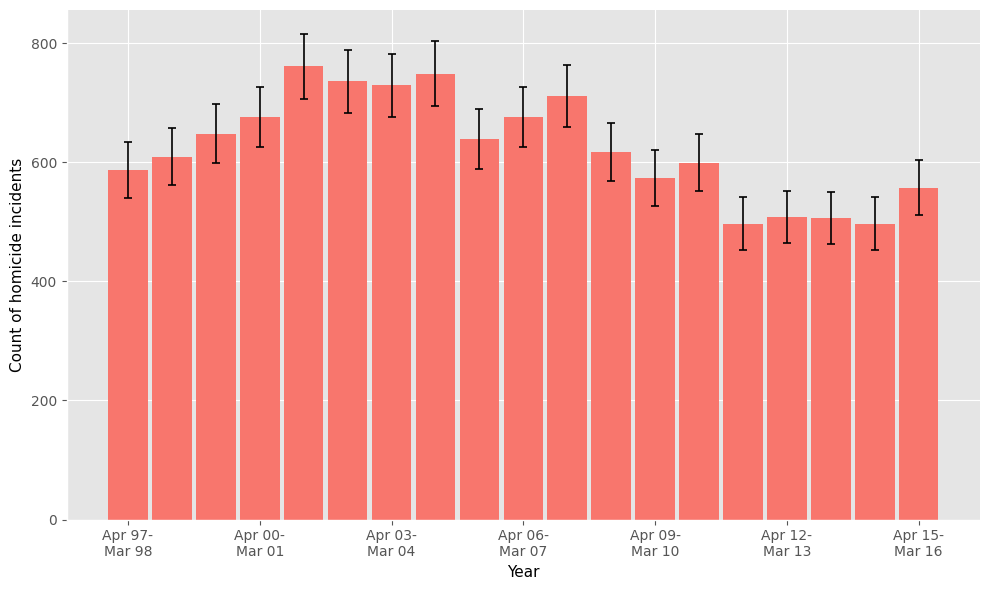

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("homocide-trends-x.csv")

plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(10, 6))


ax.bar(df['Year'], df['CountOfHomicideIncidents'], color='#F8766D', width=0.9)

lower_error = df['CountOfHomicideIncidents'] - df['Lower95CI']
upper_error = df['Upper95CI'] - df['CountOfHomicideIncidents']

ax.errorbar(
    df['Year'], df['CountOfHomicideIncidents'], 
    yerr=[lower_error, upper_error], 
    fmt='none',       
    ecolor='black',      
    capsize=3,          
    elinewidth=1.2,      
    capthick=1.2         
)


x_breaks = np.arange(1997, 2016, 3)

year_labels = [
    "Apr 97-\nMar 98", "Apr 00-\nMar 01", "Apr 03-\nMar 04", 
    "Apr 06-\nMar 07", "Apr 09-\nMar 10", "Apr 12-\nMar 13", 
    "Apr 15-\nMar 16"
]

ax.set_xticks(x_breaks)
ax.set_xticklabels(year_labels)
ax.set_xlabel("Year", fontsize=11, color='black')

y_breaks = np.arange(0, 801, 200)
ax.set_yticks(y_breaks)
ax.set_ylabel("Count of homicide incidents", fontsize=11, color='black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('homicide_plot.png', dpi=150)
plt.show()

## **Summary**

**Procedure**, not probability: The 95% confidence interval is a characteristic  
of the method, not the specific numbers you have in your hand.  
**CLT:** This is what gives us the right to use the normal distribution  
almost everywhere.  
**Metaphorical population:** Even if we have "all the data"  
(e.g., about the mortality rate for a year), we use the CI to understand  
how stable the process is (imagining that year as one in a million possible options).  